## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [36]:
import string
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os
from sklearn.model_selection import train_test_split

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [37]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

--2024-12-16 20:37:01--  https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2024-12-16 20:37:01 ERROR 404: Not Found.



FileNotFoundError: [Errno 2] No such file or directory: 'sonnets.txt'

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [ ]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

### Data loading: "Евгений Онегин"


In [38]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = [x.replace('\t\t', '') for x in text]

--2024-12-16 20:37:06--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt.4’

onegin.txt.4        100%[===================>] 256.37K  1.49MB/s    in 0.2s    

2024-12-16 20:37:07 (1.49 MB/s) - ‘onegin.txt.4’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [46]:
# Join all the strings into one and lowercase it
# Put result into variable text.

lower_case_text = ''.join(text).lower()


Put all the characters, that you've seen in the text, into variable `tokens`.

In [47]:
tokens = sorted(set(lower_case_text))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [48]:
# dict <index>:<char>
idx_to_token = {idx: char for idx, char in enumerate(tokens)}

# dict <char>:<index>
token_to_idx = {char: idx for idx, char in enumerate(tokens)}

*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [60]:
char_to_idx = token_to_idx
idx_to_char = idx_to_token
vocab_size = len(tokens)
data_ix = [char_to_idx[ch] for ch in lower_case_text]

In [61]:
hidden_size = 128
embedding_dim = 64
seq_length = 50
batch_size = 64

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(1, batch_size, self.hidden_size)

model = CharRNN(vocab_size, embedding_dim, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), 0.01)

In [62]:
def get_batches(data_ix, seq_length, batch_size):
    total_len = len(data_ix)
    n_batches = (total_len - 1) // (batch_size * seq_length)
    data_ix_trim = data_ix[:n_batches * batch_size * seq_length + 1]

    x = np.array(data_ix_trim[:-1])
    y = np.array(data_ix_trim[1:])
    x = x.reshape(batch_size, -1)
    y = y.reshape(batch_size, -1)

    for i in range(0, x.shape[1], seq_length):
        x_batch = x[:, i:i+seq_length]
        y_batch = y[:, i:i+seq_length]
        yield torch.tensor(x_batch, dtype=torch.long), torch.tensor(y_batch, dtype=torch.long)

Plot the loss function (axis X: number of epochs, axis Y: loss function).

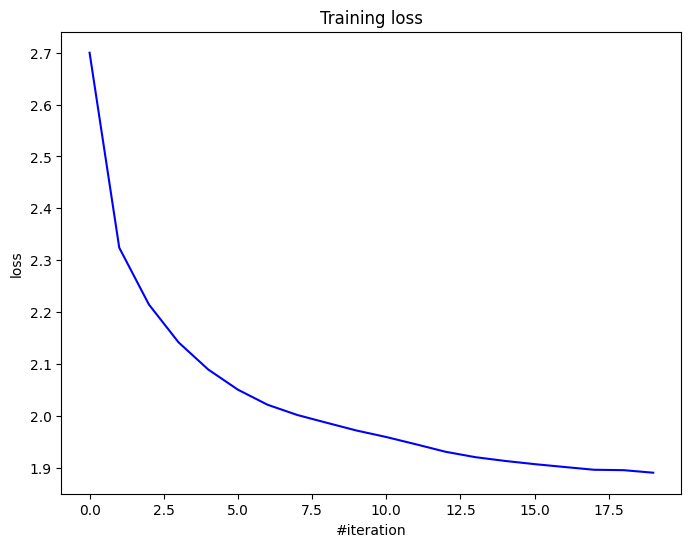

Current loss: 1.890064


In [63]:
loss_history = []

for epoch in range(20):
    h = model.init_hidden(batch_size)
    epoch_loss = 0
    count = 0

    for x_batch, y_batch in get_batches(data_ix, seq_length, batch_size):
        h = h.detach()

        optimizer.zero_grad()

        out, h = model(x_batch, h)
        out = out.reshape(-1, vocab_size)
        y_batch = y_batch.reshape(-1)

        loss = criterion(out, y_batch)
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        count += 1

    avg_loss = epoch_loss / count
    loss_history.append(avg_loss)
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss_history[-1])



In [64]:
def generate_text(model, seed_str, max_length, temperature):
    h = model.init_hidden(1)

    input_seq = torch.tensor([[char_to_idx[ch] for ch in seed_str]], dtype=torch.long)

    for i in range(len(seed_str)-1):
        _, h = model(input_seq[:, i].view(1, 1), h)

    out_chars = list(seed_str)
    last_char = input_seq[:, -1]

    for i in range(max_length - len(seed_str)):
        out, h = model(last_char.view(1, 1), h)
        logits = out[0, 0, :] / temperature
        probs = torch.softmax(logits, dim=-1).detach().numpy()
        next_char_idx = np.random.choice(vocab_size, p=probs)
        out_chars.append(idx_to_char[next_char_idx])
        last_char = torch.tensor([next_char_idx], dtype=torch.long)

    return ''.join(out_chars)

# An example of generated text.
for temp in [0.1, 0.2, 0.5, 1.0, 2.0]:
    new_text = generate_text(model, seed_str="мой дядя самых честных правил ", max_length=300, temperature=temp)
    print(' ')
    print(temp)
    print(new_text)
    print(' ')

 
0.1
мой дядя самых честных правил он в сердце в сердце в сердце страданье страданье в сердце в сердце в сердце страданье,
и в сердце страданье в сердце страданье в сердце в сердце страданье в сердце в сердце страданье в сердце в сердце девиц мой души страданье в сердце в сердце в сердце в сердце в сердц
 
 
0.2
мой дядя самых честных правил он послушный страданье
не приведит полный души страданьем стровью страстной томный страданье вечер простить и в том страсть и в сердца страсть и простов и в сердце в сердце простовь мой души страданье страданье в сердце привет страданьем другой страданье души сердце вес
 
 
0.5
мой дядя самых честных правил он простой думаньем все крава в одна,
в ней кровно я все глядит модных под ней друзья,
и в своей моей нет рассподы;
онегин в молодной
он печительный пред эту мой он в скучный предруг души летит,
когда же скрыли старинный стровью слез,
и моем мои девь страженье послушный
 
 
1.0
мой дядя самых честных правил сурества,
онегин душлым ясна тебе
тур

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [ ]:
# Не успеваю(

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [ ]:
#### Попытался сделать для RNN

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [65]:
# Saving and loading code here
torch.save(model.state_dict(), 'rnn_model.pth')

In [66]:
loaded_model = CharRNN(vocab_size, embedding_dim, hidden_size)
loaded_model.load_state_dict(torch.load('rnn_model.pth'))
loaded_model.eval()

seed = "мой дядя самых честных правил "
for temp in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print(f"Temperature = {temp}")
    print(generate_text(loaded_model, seed_str=seed, max_length=300, temperature=temp))

<ipython-input-66-3119e4dfb8fa>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('rnn_model.pth'))


Temperature = 0.1
мой дядя самых честных правил он в сердце приведит страданье,
и в сердце в сердце в сердце в сердце в сердце в сердце весно в сердце в сердце души страданье,
и в сердце в сердце в сердце приветный послушный стариков страданье,
и в сердце в сердце в сердце в сердце в сердце в сердце в сердце в сердце
Temperature = 0.2
мой дядя самых честных правил он приведит страстный души страданье,
и в томный страсть и души страданье,
в том старину ей стражу в сердце молодной души страданье,
и в сердце под этой под этой души послушный раздался в сердце страждый страдать может своей души страданье,
как не послушный страсть в се
Temperature = 0.5
мой дядя самых честных правил не впеду между томной перед мое деливой душа молодной
в в останье страстный сень свет и модный поле поэта,
нет не нам наши не был тани гордто души строгнула повсе не полно все душа терпеду послушный пред важный своей друзью привесь евгений томный весный на бедной думал 
Temperature = 1.0
мой дядя самых честных пр

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)